In [ ]:
pip install neurokit2


In [ ]:
import neurokit2 as pp

In [ ]:
pip install wfdb

In [ ]:
import wfdb

# Example: BIDMC PPG and Respiration Dataset
record = wfdb.rdrecord('bidmc01', pn_dir='bidmc')
ppg = record.p_signal[:, 1]  # PPG channel
fs = record.fs

print("Sampling Rate:", fs)
print("Signal Length:", len(ppg))


Sampling Rate: 125
Signal Length: 60001


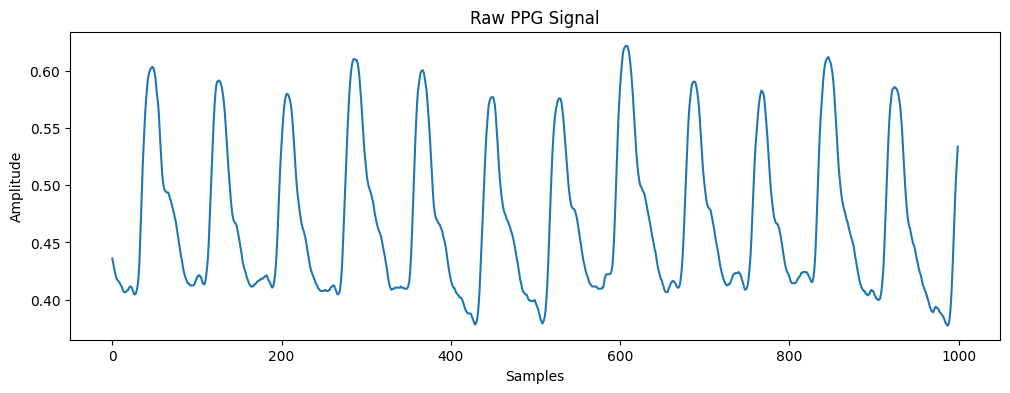

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ppg[:1000])
plt.title("Raw PPG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


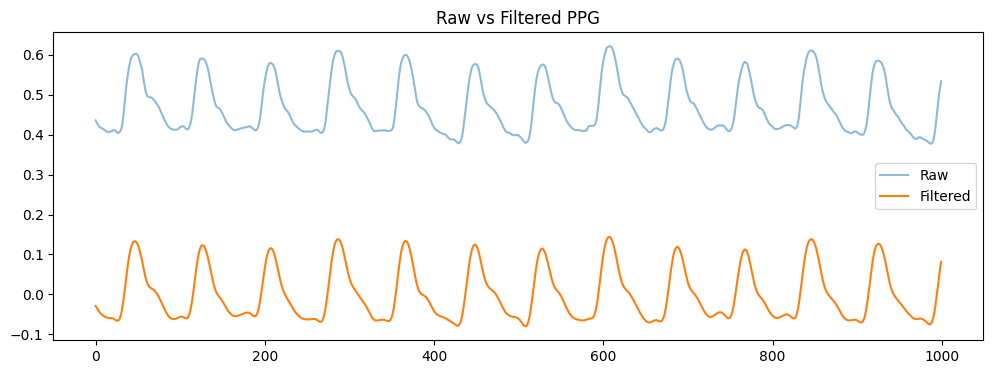

In [ ]:

ppg_clean = pp.ppg_clean(ppg, sampling_rate=fs)

plt.figure(figsize=(12,4))
plt.plot(ppg[:1000], label="Raw", alpha=0.5)
plt.plot(ppg_clean[:1000], label="Filtered")
plt.legend()
plt.title("Raw vs Filtered PPG")
plt.show()


/usr/local/lib/python3.12/dist-packages/neurokit2/epochs/epochs_create.py:180: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude=["int", "int64"]).replace({0.0: np.nan}, inplace=True)


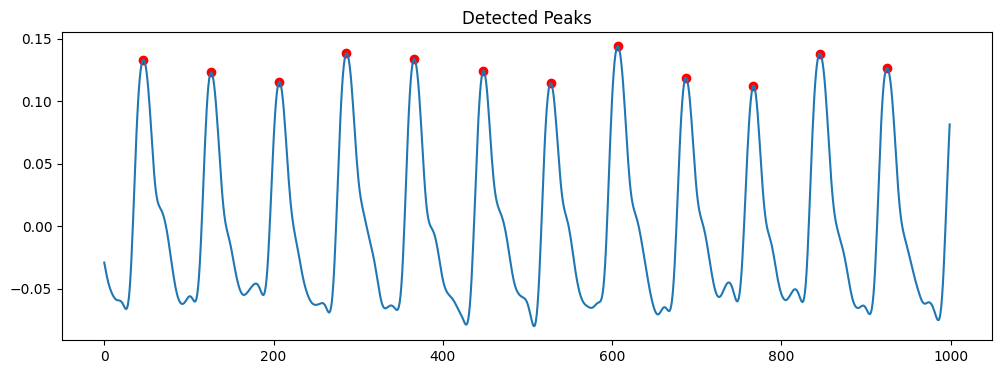

In [ ]:
signals, info = pp.ppg_process(ppg, sampling_rate=fs)

plt.figure(figsize=(12,4))
plt.plot(signals["PPG_Clean"][:1000])
plt.scatter(info["PPG_Peaks"][info["PPG_Peaks"] < 1000],
            signals["PPG_Clean"][info["PPG_Peaks"][info["PPG_Peaks"] < 1000]],
            color="red")
plt.title("Detected Peaks")
plt.show()


In [ ]:
hrv_time = pp.hrv_time(info, sampling_rate=fs)
print(hrv_time.head())


   HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  666.347705  109.936048   24.531351   61.874144   15.222437   71.332648   

   HRV_SDANN5  HRV_SDNNI5   HRV_RMSSD    HRV_SDSD  ...  HRV_IQRNN  \
0         NaN         NaN  121.414504  121.499139  ...       16.0   

   HRV_SDRMSSD  HRV_Prc20NN  HRV_Prc80NN  HRV_pNN50  HRV_pNN20  HRV_MinNN  \
0     0.905461        648.0        664.0    4.72879  15.438108      360.0   

   HRV_MaxNN   HRV_HTI  HRV_TINN  
0     2448.0  3.359813       0.0  

[1 rows x 25 columns]
